# Assignment 1 - Exercise Setup
This notebook contains the necessary code setup for the accompanying exercises. 

# 1. Coordinate Descent

In [ ]:
def argmin_x1(x):
    """Your code here"""

def argmin_x2(x):
    """Your code here"""

def argmin_x3(x):
    """Your code here"""

def f(x):
    """Your code here"""

def coordinate_descent(f, argmin, x0, max_iter=100, verbose=False):
    """Your code here"""
    for i in range(max_iter):
        # And here
        pass

# 2. Gradient Descent

In [ ]:
def f(x):
    """Your code here"""

def gradient_descent(f, grad_f, eta, u0, v0, max_iter=100) -> tuple[list, list]:
    """Your code here"""

def eta_const(t,c=1e-3) -> float:
    """Your code here"""

def eta_sqrt(t,c=1e-3) -> float:
    """Your code here"""

def eta_multistep(t, milestones=[20, 50], c=1e-4, eta_init=1e-3) -> float:
    """Your code here"""

# 3. Polynomial Regression

In [111]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load the dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame
# The description of this dataset applies to the data provided over Canvas
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [123]:
import pandas as pd

# Adapt path
df = pd.read_csv("california_housing_with_split.csv")

train = df[df["split"] == "train"]
test  = df[df["split"] == "test"]

X_train = train.drop(columns=["MedHouseVal", "split"])
y_train = train["MedHouseVal"]

X_test = test.drop(columns=["MedHouseVal", "split"])
y_test = test["MedHouseVal"]

In [124]:
# standardization

from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()
X_train_scaled = standard_scaler.fit_transform(X_train)
X_test_scaled = standard_scaler.transform(X_test)

In [125]:
# 3a linear model

from sklearn.linear_model import LinearRegression
from IPython.display import display, Math
from sklearn.metrics import mean_squared_error

feature_names = X_train.columns

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)
mse_linear_model = mean_squared_error(y_test, y_pred_linear)

linear_model_coef = dict(zip(feature_names, linear_model.coef_))

print("Linear model metrics:")
display(Math(f"\\beta_{{\\text{{MedInc}}}} = {linear_model_coef['MedInc']:.6f}"))
display(Math(f"\\beta_{{\\text{{AveBedrms}}}} = {linear_model_coef['AveBedrms']:.6f}"))
display(Math(f"\\beta_{{\\text{{HouseAge}}}} = {linear_model_coef['HouseAge']:.6f}"))
display(Math(f"\\text{{MSE}}_{{\\text{{test}}}} = {mse_linear_model:.6f}"))

Linear model metrics:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [126]:
# 3a polynomial model

from sklearn.preprocessing import PolynomialFeatures

polynomial_features = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = polynomial_features.fit_transform(X_train_scaled)
X_test_poly = polynomial_features.transform(X_test_scaled)

polynomial_model = LinearRegression()
polynomial_model.fit(X_train_poly, y_train)

y_pred_poly = polynomial_model.predict(X_test_poly)
mse_poly_model = mean_squared_error(y_test, y_pred_poly)

polynomial_feature_names = polynomial_features.get_feature_names_out(feature_names)
poly_model_coef = dict(zip(polynomial_feature_names, polynomial_model.coef_))

print("Polynomial model metrics:")
display(Math(f"\\beta_{{\\text{{MedInc}}}} = {poly_model_coef['MedInc']:.6f}"))
display(Math(f"\\beta_{{\\text{{MedInc}} \\cdot \\text{{AveBedrms}}}} = {poly_model_coef['MedInc AveBedrms']:.6f}"))
display(Math(f"\\beta_{{\\text{{HouseAge}} \\cdot \\text{{AveBedrms}}}} = {poly_model_coef['HouseAge AveBedrms']:.6f}"))
display(Math(f"\\text{{MSE}}_{{\\text{{test}}}} = {mse_poly_model:.6f}"))

Polynomial model metrics:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [127]:
# 3b ridge model

from sklearn.linear_model import Ridge

# objective is min (1/n) * ||y - Xb||^2 + lambda * ||b||^2 <=> min ||y - Xb||^2 + n * lambda * ||b||^2
# min b does not change if we multiply the objective by n

n_train_samples = X_train_poly.shape[0]
lambdaa = 0.001

# from https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html
# ||y - Xw||^2 + alpha * ||w||^2
alpha = lambdaa * n_train_samples

ridge_model = Ridge(alpha=alpha)
ridge_model.fit(X_train_poly, y_train)
    
y_pred_ridge = ridge_model.predict(X_test_poly)
mse_ridge_model = mean_squared_error(y_test, y_pred_ridge)

ridge_model_coef = dict(zip(polynomial_feature_names, ridge_model.coef_))

print("Ridge model metrics:")
display(Math(f"\\beta_{{\\text{{MedInc}}}} = {ridge_model_coef['MedInc']:.6f}"))
display(Math(f"\\beta_{{\\text{{MedInc}} \\cdot \\text{{AveBedrms}}}} = {ridge_model_coef['MedInc AveBedrms']:.6f}"))
display(Math(f"\\beta_{{\\text{{HouseAge}} \\cdot \\text{{AveBedrms}}}} = {ridge_model_coef['HouseAge AveBedrms']:.6f}"))
display(Math(f"\\text{{MSE}}_{{\\text{{test}}}} = {mse_ridge_model:.6f}"))



Ridge model metrics:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# 5. Naive Bayes

In [ ]:
from sklearn.datasets import fetch_20newsgroups
categories = ['sci.space', 'misc.forsale', 'comp.graphics', 'rec.sport.hockey']
train = fetch_20newsgroups(subset='train', categories=categories)
test = fetch_20newsgroups(subset='test', categories=categories)

print(train.DESCR)

The classes are indicated categorically with indices from zero to two by the target vector. The target names tell us which index belongs to which class.

In [ ]:
y_train = train.target
y_train

In [ ]:
train.target_names

We represent the documents in a bag of word format. That is, we create a data matrix ``D`` such that ``D[j,i]=1`` if the j-th document contains the i-th feature (word), and ``D[j,i]=0`` otherwise. 

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
vectorizer = CountVectorizer(stop_words="english", min_df=5,token_pattern=r"[^\W\d_]+", binary=True)
D = vectorizer.fit_transform(train.data)
D_test = vectorizer.transform(test.data)

We get the allocation of feature indices to words by the following array, containing the vocabulary.

In [ ]:
vectorizer.get_feature_names_out()

For example, the word `zubov` has the index 7383.

In [ ]:
np.where(vectorizer.get_feature_names_out() == 'zubov')[0]

# 6. Lasso vs Ridge Regression (for checking)

In [128]:
# load data

import pandas as pd
df = pd.read_csv("METABRIC_RNA_Mutation.csv")
df_D = pd.concat([df['age_at_diagnosis'], df.iloc[:, 31:520]],axis=1)
D = df_D.to_numpy()
y = df['overall_survival_months'].to_numpy()

/tmp/ipykernel_12464/3110539904.py:4: DtypeWarning: Columns (0: rasgef1b_mut, 1: hras_mut, 2: smarcb1_mut, 3: siah1_mut) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("METABRIC_RNA_Mutation.csv")


In [129]:
import numpy as np

n, _ = D.shape
X = np.column_stack((np.ones(n), D))
X.shape

(1904, 491)

In [130]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold


#\beta = (X^T X + 2n\lambda L)^{-1} X^T y
def fit_ridge_model(X, y, lambdaa):
    p = X.shape[1]
    I = np.eye(p)
    I[0, 0] = 0
    return np.linalg.pinv(X.T @ X + 2 * n * lambdaa * I) @ X.T @ y

def predict_ridge_model(X, beta):
    return X @ beta

kf = KFold(n_splits=5, shuffle=True, random_state=69)
lambdas = np.logspace(-10, 1, 20)

all = []
for lambdaa in lambdas:
    ridge_train_mse, ridge_test_mse, ridge_features = [], [], []
    lasso_train_mse, lasso_test_mse, lasso_features = [], [], []
    for train_index, test_index in kf.split(X):
        X_train_, X_test_ = X[train_index], X[test_index]
        D_train, D_test = D[train_index], D[test_index]
        y_train_, y_test_ = y[train_index], y[test_index]
        
        # ridge
        beta_ridge = fit_ridge_model(X_train_, y_train_, lambdaa)
        y_pred_ridge_train = predict_ridge_model(X_train_, beta_ridge)
        y_pred_ridge_test = predict_ridge_model(X_test_, beta_ridge)
        
        ridge_train_mse.append(mean_squared_error(y_train_, y_pred_ridge_train))
        ridge_test_mse.append(mean_squared_error(y_test_, y_pred_ridge_test))
        ridge_features.append(np.sum(np.abs(beta_ridge[1:]) > 1e-16))
        
        # lasso
        model_lasso = Lasso(alpha=lambdaa, fit_intercept=True, max_iter=10000)
        model_lasso.fit(D_train, y_train_)
        y_pred_lasso_train = model_lasso.predict(D_train)
        y_pred_lasso_test = model_lasso.predict(D_test)
        
        lasso_train_mse.append(mean_squared_error(y_train_, y_pred_lasso_train))
        lasso_test_mse.append(mean_squared_error(y_test_, y_pred_lasso_test))
        lasso_features.append(np.sum(np.abs(model_lasso.coef_[1:]) > 1e-16))
        
    ridge_data = {"ridge_train_mse": np.mean(ridge_train_mse), "ridge_test_mse": np.mean(ridge_test_mse), "ridge_features": np.mean(ridge_features)}
    lasso_data = {"lasso_train_mse": np.mean(lasso_train_mse), "lasso_test_mse": np.mean(lasso_test_mse), "lasso_features": np.mean(lasso_features)}
    
    all.append({
        'lambda': lambdaa, **ridge_data, **lasso_data
    })
    
    all_df = pd.DataFrame(all)

In [131]:
all_df.head()

,lambda,ridge_train_mse,ridge_test_mse,ridge_features,lasso_train_mse,lasso_test_mse,lasso_features
0,1.000000e-10,3247.440039,7441.679541,490.0,3247.440039,7441.679548,489.0
1,3.792690e-10,3247.440039,7441.679516,490.0,3247.440039,7441.679547,489.0
2,1.438450e-09,3247.440039,7441.679425,490.0,3247.440039,7441.679539,489.0
3,5.455595e-09,3247.440039,7441.679077,490.0,3247.440039,7441.679512,489.0
4,2.069138e-08,3247.440039,7441.677757,490.0,3247.440039,7441.679407,489.0


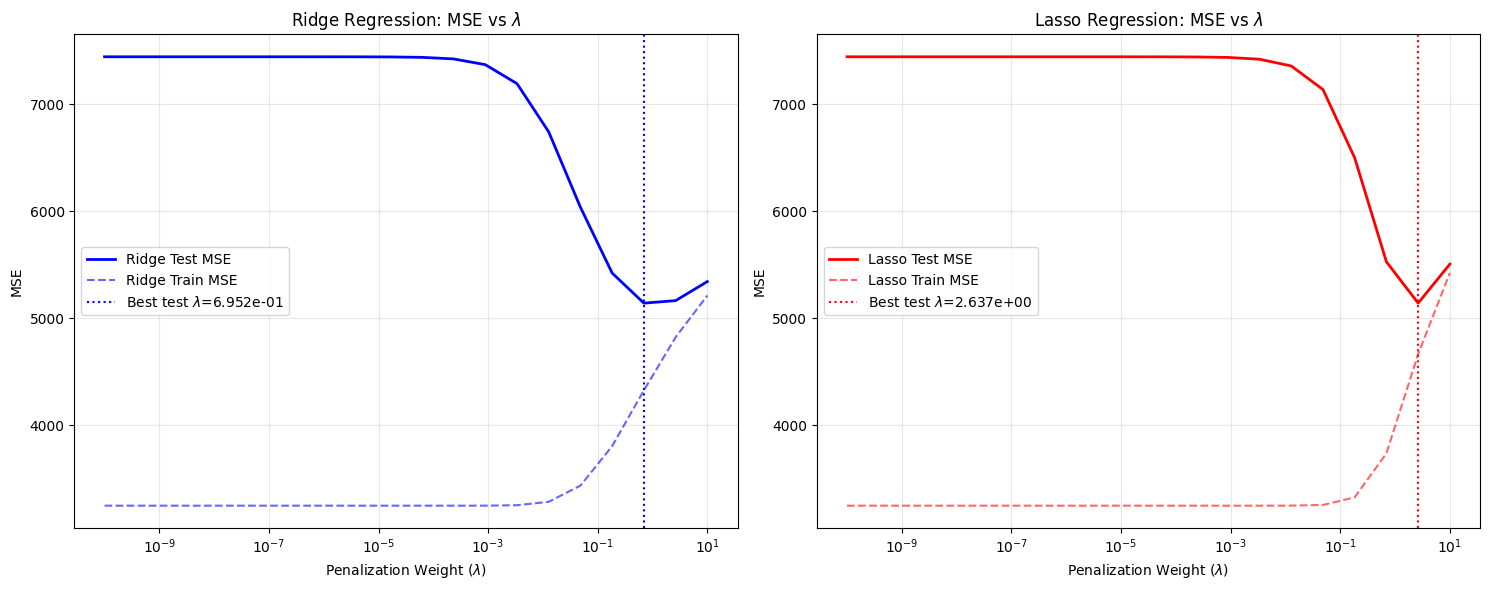

In [132]:
# 6a plot

import matplotlib.pyplot as plt

best_test_lambda_ridge = all_df.loc[all_df['ridge_test_mse'].idxmin(), 'lambda']
best_test_lambda_lasso = all_df.loc[all_df['lasso_test_mse'].idxmin(), 'lambda']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].plot(all_df['lambda'], all_df['ridge_test_mse'], label='Ridge Test MSE', color='blue', lw=2)
axes[0].plot(all_df['lambda'], all_df['ridge_train_mse'], '--', label='Ridge Train MSE', color='blue', alpha=0.6)
axes[0].set_xscale('log')
axes[0].set_title(r'Ridge Regression: MSE vs $\lambda$')
axes[0].set_xlabel(r'Penalization Weight ($\lambda$)')
axes[0].axvline(best_test_lambda_ridge, color='blue', linestyle=':', label=rf'Best test $\lambda$={best_test_lambda_ridge:.3e}')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(all_df['lambda'], all_df['lasso_test_mse'], label='Lasso Test MSE', color='red', lw=2)
axes[1].plot(all_df['lambda'], all_df['lasso_train_mse'], '--', label='Lasso Train MSE', color='red', alpha=0.6)
axes[1].set_xscale('log')
axes[1].set_title(r'Lasso Regression: MSE vs $\lambda$')
axes[1].set_xlabel(r'Penalization Weight ($\lambda$)')
axes[1].axvline(best_test_lambda_lasso, color='red', linestyle=':', label=rf'Best test $\lambda$={best_test_lambda_lasso:.3e}')
axes[1].set_ylabel('MSE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


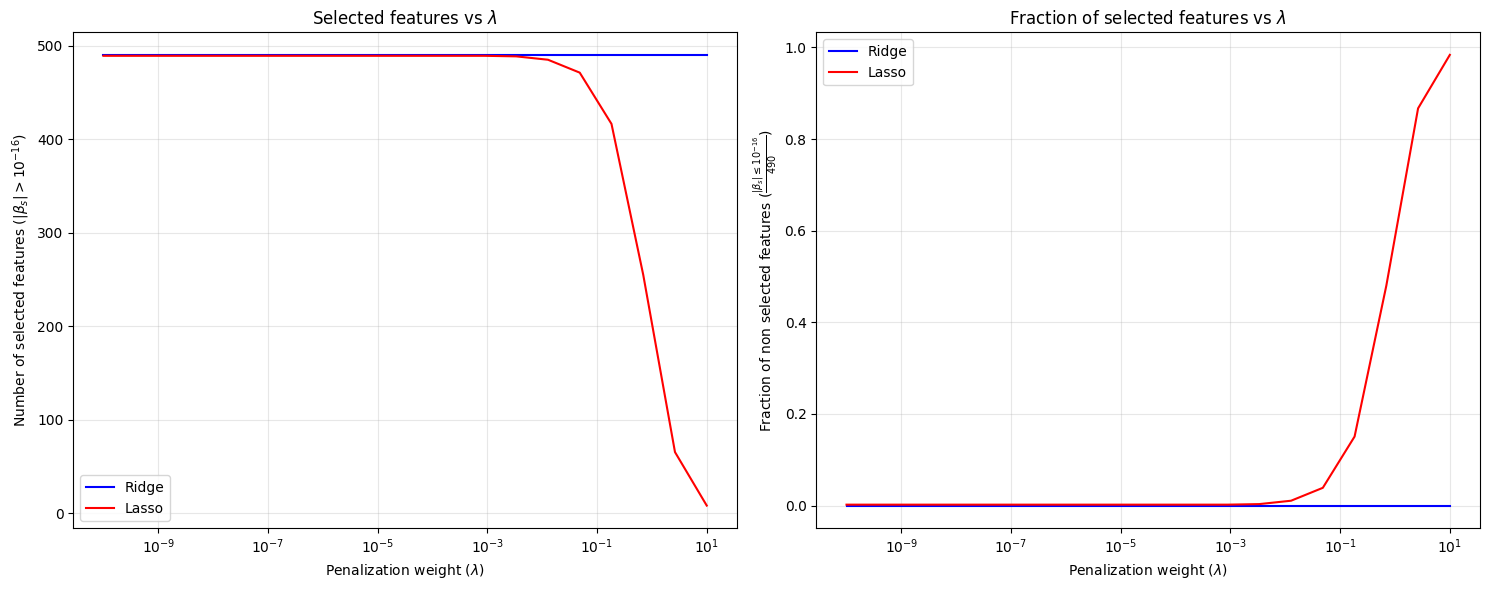

In [133]:
# 6b plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].plot(all_df['lambda'], all_df['ridge_features'], label='Ridge', color='blue')
axes[0].plot(all_df['lambda'], all_df['lasso_features'], label='Lasso', color='red')
axes[0].set_xscale('log')
axes[0].set_xscale('log')
axes[0].set_title(r'Selected features vs $\lambda$')
axes[0].set_title(r'Selected features vs $\lambda$')
axes[0].set_xlabel(r'Penalization weight ($\lambda$)')
axes[0].set_xlabel(r'Penalization weight ($\lambda$)')
axes[0].set_ylabel(r'Number of selected features ($|\beta_s| > 10^{-16}$)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#fraction of zero coefficients
p = X.shape[1] - 1
axes[1].plot(all_df['lambda'], (p - all_df['ridge_features']) / p, label='Ridge', color='blue')
axes[1].plot(all_df['lambda'], (p - all_df['lasso_features']) / p, label='Lasso', color='red')
axes[1].set_xscale('log')
axes[1].set_title(r'Fraction of selected features vs $\lambda$')
axes[1].set_xlabel(r'Penalization weight ($\lambda$)')
axes[1].set_ylabel(rf'Fraction of non selected features ($\frac{{|\beta_s| \leq 10^{{-16}}}}{{{p}}}$)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()